# **Loading Dataset from Google Colab**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

root = "/content/drive/MyDrive/Bird_Species_Detection"
ckpt_path = f"{root}/files/ViT-B16/ViT-B16-Training2/vit_checkpoint.pth"
preds_path = f"{root}/files/ViT-B16/ViT-B16-Training2/test_preds.npy"
labels_path = f"{root}/files/ViT-B16/ViT-B16-Training2/test_labels.npy"
train_loss_path = f"{root}/files/ViT-B16/ViT-B16-Training2/train_losses.npy"
test_loss_path  = f"{root}/files/ViT-B16/ViT-B16-Training2/test_losses.npy"

Mounted at /content/drive


# **Installing Dependencies**

In [2]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import classification_report, confusion_matrix
    import os
    import cv2
    from tqdm import tqdm
    import timm
    import torch
    import torchvision
    from torchvision import transforms
    import torchaudio
    import torch.nn as nn
    from torch.utils.data import DataLoader, Dataset
    from IPython.display import Javascript
    from IPython.display import display
    print("All Dependencies already installed")
except ImportError:
    !pip install timm torch torchvision torchaudio matplotlib opencv-python tqdm scikit-learn --quiet

All Dependencies already installed


In [3]:
images_df = pd.read_csv(f"{root}/images.txt", sep=" ", names=["img_id", "path"])
labels_df = pd.read_csv(f"{root}/image_class_labels.txt", sep=" ", names=["img_id", "label"])
split_df  = pd.read_csv(f"{root}/train_test_split.txt", sep=" ", names=["img_id", "is_train"])

data_df = images_df.merge(labels_df, on="img_id").merge(split_df, on="img_id")

train_df = data_df[data_df["is_train"] == 1].reset_index(drop=True)
test_df  = data_df[data_df["is_train"] == 0].reset_index(drop=True)

In [4]:
data_df

,img_id,path,label,is_train
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1
...,...,...,...,...
11783,11784,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,1
11784,11785,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,0
11785,11786,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,0
11786,11787,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,1


# **Transformations**

In [5]:
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# **Building Up a Custom Dataset**

In [6]:
class BirdDataset(Dataset):
    def __init__(self, dataframe, root, transforms=None):
        self.df = dataframe
        self.root = os.path.join(root, "images")
        self.transforms = transforms

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root, row["path"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transforms:
            img = self.transforms(img)
        label = torch.tensor(row["label"] - 1, dtype=torch.long)  # 0-indexed
        return img, label

    def __len__(self):
        return len(self.df)

train_dataset = BirdDataset(train_df, root, transforms=train_transforms)
test_dataset  = BirdDataset(test_df, root, transforms=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# **Device Setup**

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Currently using device: {device}")

Currently using device: cuda


# **ViT Model Setup**

In [8]:
num_classes = len(train_df["label"].unique())

# Load pretrained Vision Transformer
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)

# **Training Loop**

## **Load Losses for all data [Training / Testing]**

In [10]:
train_losses, test_losses = [], []

if os.path.exists(train_loss_path):
    train_losses = np.load(train_loss_path).tolist()
    print(f"📂 Loaded {len(train_losses)} previous training losses")

if os.path.exists(test_loss_path):
    test_losses = np.load(test_loss_path).tolist()
    print(f"📂 Loaded {len(test_losses)} previous testing losses")

📂 Loaded 50 previous training losses
📂 Loaded 1 previous testing losses


In [11]:
print(f"Training Losses : {train_losses}")
print(f"No. of Training Losses : {len(train_losses)}")
print(f"Testing Losses : {test_losses}")
print(f"No. of Testing Losses : {len(test_losses)}")

Training Losses : [3.018166811859354, 0.5110286487702359, 0.11302780974260036, 0.027785960872201844, 0.01052232243447624, 0.005973702749891325, 0.0044710777335839865, 0.00436295165328626, 0.0022181248331957673, 0.0017507299861345598, 0.0014312185094434214, 0.001169450749194824, 0.0009885544837898318, 0.0008485636880071438, 0.0007197792840591493, 0.0006233657085760298, 0.0005366428341268205, 0.0004674439639549088, 0.0004024441747807283, 0.0003515262892989917, 0.00031002511860470864, 0.00027049582917862473, 0.00023805819302574394, 0.00020845805626409624, 0.00018537400907742732, 0.00016298682454904105, 0.00014383539905309667, 0.0001259302147484553, 0.00011175408968831998, 9.935644951102849e-05, 8.873146826443461e-05, 7.720607087282994e-05, 6.837562182710749e-05, 6.079431241619688e-05, 5.3961878407751506e-05, 4.79283792803007e-05, 4.2180039812631144e-05, 3.770767901361514e-05, 3.3054488549749564e-05, 2.904549648248692e-05, 2.5946079423444277e-05, 2.2969750368266684e-05, 2.0318978918209163e

## **Saving and Loading Checkpoints**

In [12]:
def save_checkpoint(epoch, model, optimizer, filename=ckpt_path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, filename)
    print(f"💾 Checkpoint saved at epoch {epoch+1}")

def load_checkpoint(model, optimizer, filename=ckpt_path):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"🔄 Resumed from epoch {checkpoint['epoch']+1}")
    return checkpoint['epoch'] + 1

def autosave_notebook():
    display(Javascript('IPython.notebook.save_checkpoint();'))

In [13]:
start_epoch = 0
epochs = 50

if os.path.exists(ckpt_path):
    start_epoch = load_checkpoint(model, optimizer, ckpt_path)

for epoch in range(start_epoch, epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{running_loss/len(pbar):.4f}")

    avg_loss = running_loss / len(train_loader)
    print(f"✅ Epoch [{epoch+1}/{epochs}] completed | Avg Loss: {avg_loss:.4f}")
    train_losses.append(avg_loss)

    save_checkpoint(epoch, model, optimizer)

    autosave_notebook()
    print("📘 Notebook auto-saved.")

    np.save(train_loss_path, np.array(train_losses))
    print("💾 Training losses saved.")

print("🎉 Training completed successfully!")

🔄 Resumed from epoch 50
🎉 Training completed successfully!


# **Model Evaluation**

In [14]:
if os.path.exists(preds_path) and os.path.exists(labels_path):
    all_preds = np.load(preds_path)
    all_labels = np.load(labels_path)
    print("✅ Loaded cached predictions.")
else:
    model.eval()
    all_preds, all_labels = [], []
    running_test_loss = 0.0

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc="Evaluating"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)

            loss = criterion(outputs, labels)
            running_test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    print(f"📉 Test Loss: {avg_test_loss:.4f}")

    np.save(preds_path, np.array(all_preds))
    np.save(labels_path, np.array(all_labels))
    np.save(test_loss_path, np.array(test_losses))

    print("💾 Predictions and losses saved for future use.")

✅ Loaded cached predictions.


# **Classification Report**

📈 Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        30
           1       1.00      0.83      0.91        30
           2       0.69      0.96      0.81        28
           3       0.83      0.97      0.89        30
           4       1.00      0.86      0.92        14
           5       0.79      1.00      0.88        11
           6       1.00      1.00      1.00        23
           7       0.83      0.83      0.83        18
           8       0.44      0.38      0.41        29
           9       1.00      0.90      0.95        30
          10       0.64      0.53      0.58        30
          11       0.96      0.96      0.96        26
          12       0.96      0.87      0.91        30
          13       0.91      0.97      0.94        30
          14       0.93      0.89      0.91        28
          15       0.96      0.89      0.93        28
          16       1.00      1.00      1.00        27
  

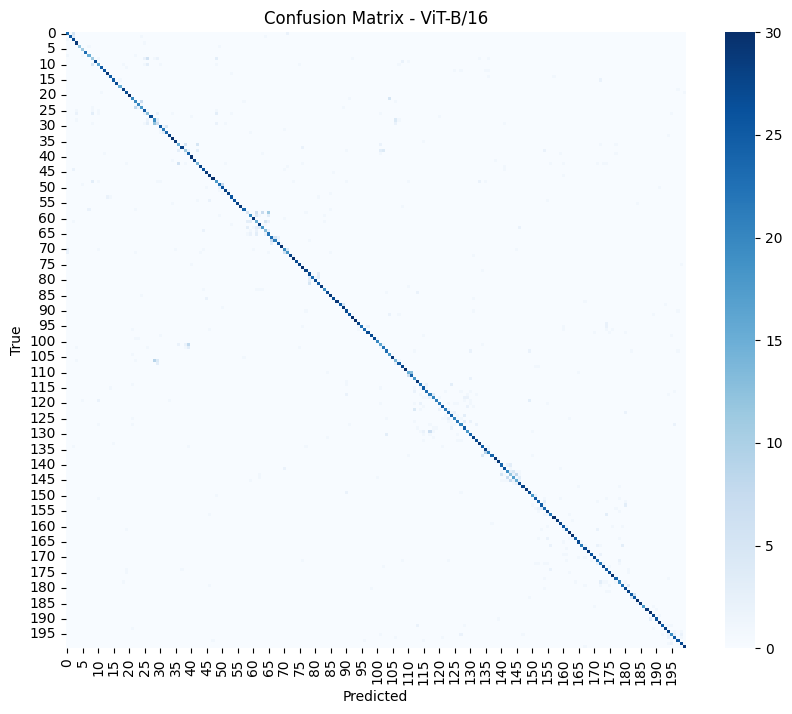

In [15]:
print("📈 Classification Report:")
print(classification_report(all_labels, all_preds, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - ViT-B/16")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

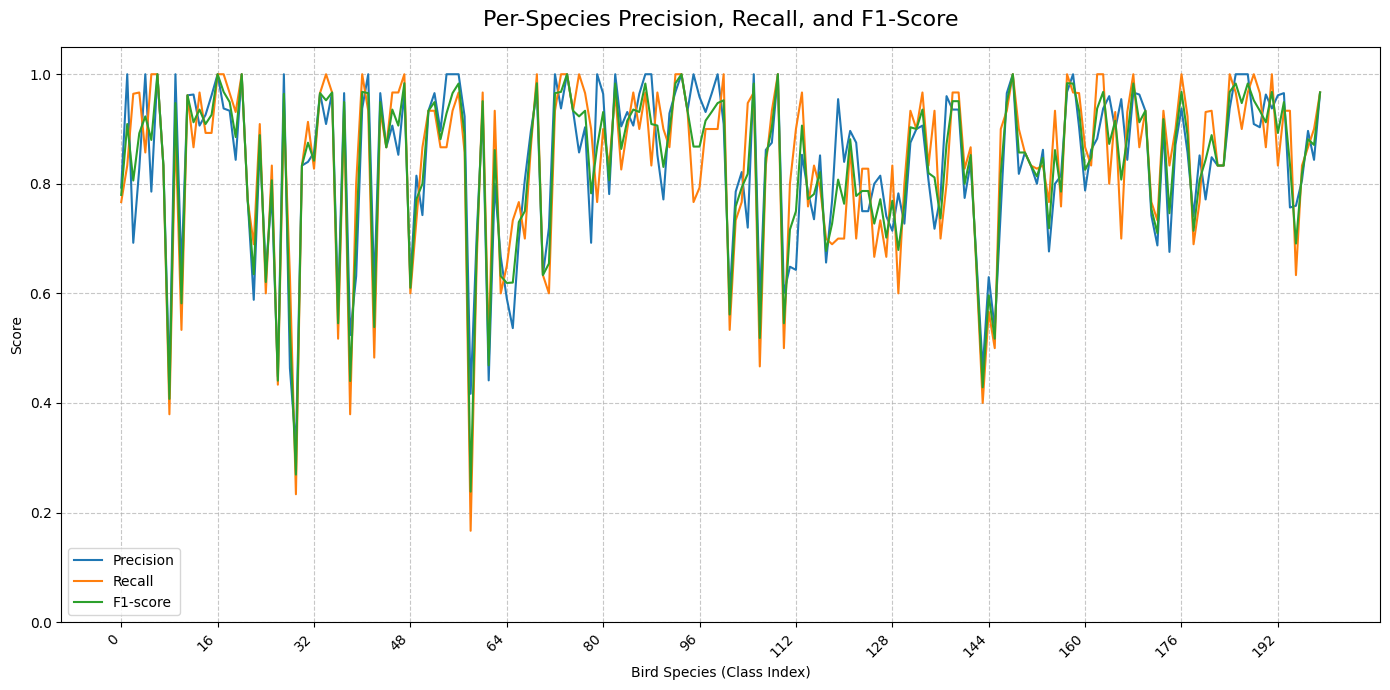

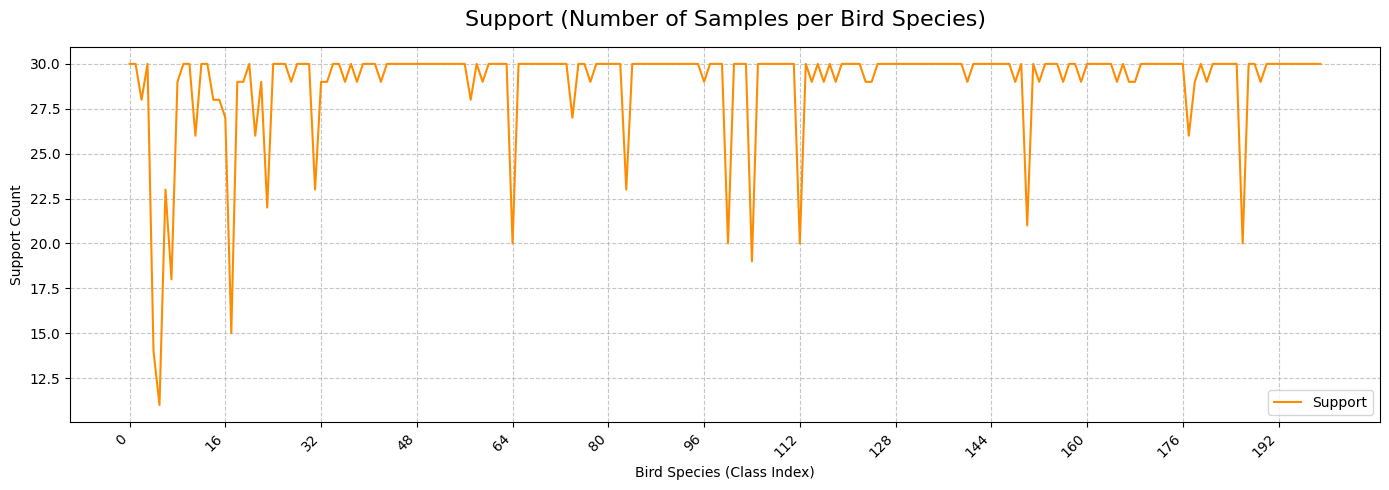

In [16]:
report = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()

# Keep only per-class rows
df_species = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Define how many ticks to show on x-axis (e.g., 10 evenly spaced labels)
num_labels = len(df_species)
max_ticks = 12  # you can adjust this for more/less density
step = max(1, num_labels // max_ticks)
tick_positions = np.arange(0, num_labels, step)
tick_labels = [df_species.index[i] for i in tick_positions]

# --- Plot Precision, Recall, F1 ---
plt.figure(figsize=(14, 7))
plt.plot(df_species.index, df_species['precision'], label='Precision')
plt.plot(df_species.index, df_species['recall'], label='Recall')
plt.plot(df_species.index, df_species['f1-score'], label='F1-score')

plt.title("Per-Species Precision, Recall, and F1-Score", fontsize=16, pad=15)
plt.xlabel("Bird Species (Class Index)")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Apply distributed x-axis labels
plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# --- Plot Support ---
plt.figure(figsize=(14, 5))
plt.plot(df_species.index, df_species['support'], color='darkorange', label='Support')

plt.title("Support (Number of Samples per Bird Species)", fontsize=16, pad=15)
plt.xlabel("Bird Species (Class Index)")
plt.ylabel("Support Count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Apply same distributed x-axis labels
plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# **Loss vs Epoch Graph**

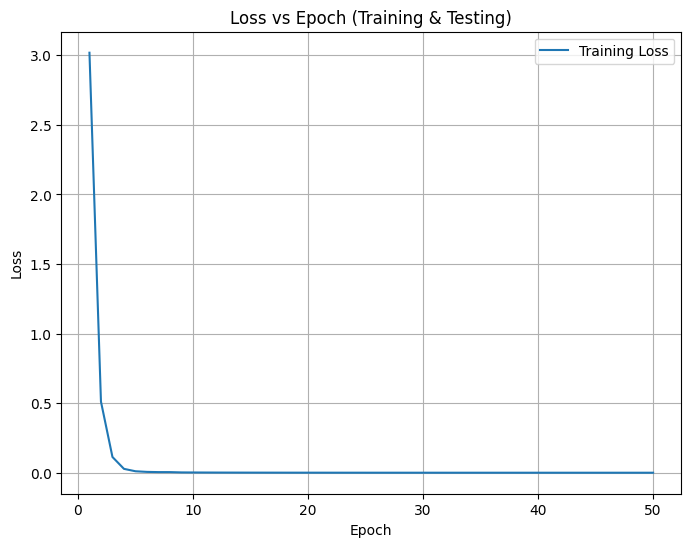

In [17]:
plt.figure(figsize=(8,6))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Training Loss')
# plt.plot(range(1, len(test_losses)+1), test_losses, label='Testing Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch (Training & Testing)')
plt.legend()
plt.grid(True)
plt.show()

# **Manual Testing**

## **PREDICT ON UNSEEN IMAGE FROM GOOGLE DRIVE + SHOW IMAGE**

In [28]:
import torch
import cv2
from torchvision import transforms
import matplotlib.pyplot as plt

# --- Define same transforms used for test data ---
predict_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Load model checkpoint ---
model.eval()
if os.path.exists(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Model weights loaded successfully for prediction!")

# --- Define prediction function ---
def predict_bird_species(image_path, model, class_names):
    """
    image_path: full path to image in Google Drive
    model: trained ViT model
    class_names: list of class labels (1..200)
    """
    # Read and preprocess image
    img = cv2.imread(image_path)
    if img is None:
        print("❌ Error: Image not found at", image_path)
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = predict_transform(img_rgb).unsqueeze(0).to(device)

    # Forward pass
    with torch.no_grad():
        outputs = model(img_tensor)
        _, pred = torch.max(outputs, 1)

    predicted_label = class_names[pred.item()]

    # --- Extract species number and name ---
    if "." in predicted_label:
        species_number, species_name = predicted_label.split(".", 1)
        species_name = species_name.replace("_", " ")
    else:
        species_number = "N/A"
        species_name = predicted_label.replace("_", " ")

    # --- Show image with formatted title ---
    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(
        f"Predicted Species Number : {species_number}\nPredicted Species Name : {species_name}",
        fontsize=13, pad=12
    )
    plt.show()

    return species_number, species_name

# --- Load class name mapping ---
classes_txt = f"{root}/classes.txt"
if os.path.exists(classes_txt):
    with open(classes_txt, "r") as f:
        class_names = [line.strip().split(" ", 1)[1] for line in f.readlines()]
else:
    class_names = [f"Species {i+1}" for i in range(num_classes)]

✅ Model weights loaded successfully for prediction!


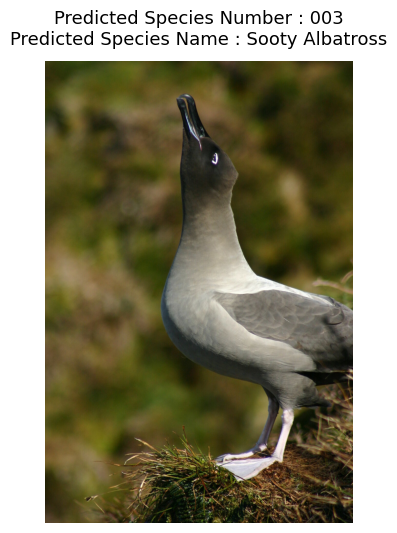

In [29]:
unseen_image_path = "/content/drive/MyDrive/Bird_Species_Detection/check_images/0032.jpg"
predicted_species = predict_bird_species(unseen_image_path, model, class_names)

## **WEB UI: Upload OR use Google Drive Path**

In [20]:
!pip install gradio --quiet

import gradio as gr
import torch
import cv2
import numpy as np
from torchvision import transforms

# --- Model checkpoint ---
model.eval()
if os.path.exists(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Model weights loaded successfully!")

# --- Load class name mapping ---
classes_txt = f"{root}/classes.txt"
if os.path.exists(classes_txt):
    with open(classes_txt, "r") as f:
        class_names = [line.strip().split(" ", 1)[1] for line in f.readlines()]
else:
    class_names = [f"Species {i+1}" for i in range(num_classes)]

# --- Transform ---
predict_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Prediction function ---
def predict_bird_species(image, drive_path):
    # Decide image source
    if image is not None:
        img_rgb = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    elif drive_path:
        img = cv2.imread(drive_path)
        if img is None:
            return "❌ Invalid Google Drive path or file not accessible.", "", None
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        return "❌ Please upload an image or provide a Google Drive path.", "", None

    # Preprocess
    img_tensor = predict_transform(img_rgb).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(img_tensor)
        _, pred = torch.max(outputs, 1)

    predicted_label = class_names[pred.item()]

    # Format
    if "." in predicted_label:
        species_number, species_name = predicted_label.split(".", 1)
        species_name = species_name.replace("_", " ")
    else:
        species_number = "N/A"
        species_name = predicted_label.replace("_", " ")

    return f"{species_number}", f"{species_name}", img_rgb


# --- Custom CSS to remove scrollbar and adjust appearance ---
custom_css = """
textarea {
    overflow: hidden !important;
    resize: none !important;
    height: 40px !important;
}
"""

# --- Interface ---
interface = gr.Interface(
    fn=predict_bird_species,
    inputs=[
        gr.Image(type="pil", label="Upload Bird Image (optional)"),
        gr.Textbox(
            label="Or Enter Google Drive Image Path",
            placeholder="/content/drive/MyDrive/.../bird.jpg",
            lines=1,          # single-line height
            max_lines=1,      # prevents resizing
        ),
    ],
    outputs=[
        gr.Textbox(label="Predicted Species Number"),
        gr.Textbox(label="Predicted Species Name"),
        gr.Image(label="Selected Image"),
    ],
    title="Bird Species Identifier (ViT-B/16)",
    description="Upload a bird image OR enter the full Google Drive path to predict the bird species.",
    theme="default",
    css=custom_css,  # apply CSS to remove scrollbars
    allow_flagging="never"
)

interface.launch(share=True)

✅ Model weights loaded successfully!


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://79b971c1b579e0a31c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
